# DESI DR1 BGS Study

In [1]:
import fitsio
import numpy as np
import healpy as hp
import pandas as pd
import seaborn as sns
from astropy.table import Table
import matplotlib.pyplot as plt
%matplotlib inline

from Simulation.simulMap import *

In [6]:
#File names:
DIR = "Data DESI/"
outputDIR = DIR + "DESI Figures/" #to save figures
output_path = outputDIR + "DESI_DR1_BGS_" #common suffix to every figures
FILE_NGC = DIR + "BGS_ANY_NGC_clustering.dat.fits"
FILE_SGC = DIR + "BGS_ANY_SGC_clustering.dat.fits"

#Reading files:
NGC = Table.read(FILE_NGC)
SGC = Table.read(FILE_SGC)
NGC

TARGETID,Z,NTILE,RA,DEC,PHOTSYS,FRAC_TLOBS_TILES,WEIGHT_ZFAIL,BITWEIGHTS,PROB_OBS,WEIGHT,WEIGHT_COMP,WEIGHT_SYS,flux_g_dered,flux_r_dered,flux_z_dered,flux_w1_dered,flux_w2_dered,NX,WEIGHT_FKP
,,,deg,deg,,,,,,,,,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy,,
int64,float64,int64,float64,float64,bytes1,float64,float64,int64[2],float64,float64,float64,float64,float32,float32,float32,float32,float32,float64,float64
39627540901396542,0.11780978798091779,1,159.21336539688306,-10.1570784990642,S,0.986125385405961,1.0,-1 .. -1,1.0,0.4020310943321785,1.0,1.0,49.759033,82.394775,123.07306,107.12112,72.68243,0.013277792318345803,0.010644577467738883
39627540901396881,0.18852438367491672,1,159.31752567050466,-10.126518405884719,S,0.986125385405961,1.0003317594528198,-1 .. -1,1.0,0.40216447194805066,1.0,1.0,4.465552,9.0119915,15.1033325,19.139269,17.25489,0.007570508503506765,0.01852072744982418
39627546827951381,0.13939738520826428,1,157.87076725654435,-9.875451258938376,S,0.98491921005386,1.0000087022781372,-1 .. -1,1.0,0.4020345929185812,1.0,1.0,21.879585,30.944036,39.23734,31.118029,17.95399,0.011543794958537013,0.012223957863869393
39627546832142517,0.13384342727980247,1,157.95311366416092,-9.89176181427952,S,0.98491921005386,1.0,-6502010112314306597 .. -7014319551088676288,0.34375,1.1524891370855783,2.8666666666666667,1.0,64.23985,161.47015,326.29388,286.1153,183.32571,0.011543794958537013,0.012223957863869393
39627546832142599,0.13481237197080895,1,157.95938723949703,-9.900573678838345,S,0.98491921005386,1.0000147819519043,-1158348146330124321 .. -90865853993600030,0.6875,0.5827278403438851,1.449438202247191,1.0,13.473231,20.69669,29.218834,22.669884,17.1243,0.011543794958537013,0.012223957863869393
39627546832144102,0.3277038731563745,1,158.0586254092098,-9.883478054340443,S,0.98491921005386,1.0,-1 .. -1,1.0,0.4020310943321785,1.0,1.0,4.8808885,13.26394,26.47439,35.094788,26.350426,0.0020923038580991644,0.0639135806306668
39627546832144556,0.2804423196541022,1,158.0919034157211,-9.885985138196315,S,0.98491921005386,1.0000360012054443,-1 .. -1,1.0,0.40204556793620055,1.0,1.0,4.8884478,10.819805,16.304056,14.631474,10.874418,0.0033096766342485067,0.041377478709825624
39627546832144612,0.1756295118675194,1,158.09744754077613,-9.948586941938014,S,0.98491921005386,1.0000108480453491,-8354376908713272321 .. -8487356173256100561,0.5390625,0.7408939110042868,1.8428571428571427,1.0,19.048483,29.186644,40.23485,27.274828,21.075787,0.008095592993999081,0.0173402934391804


## Data exoloration

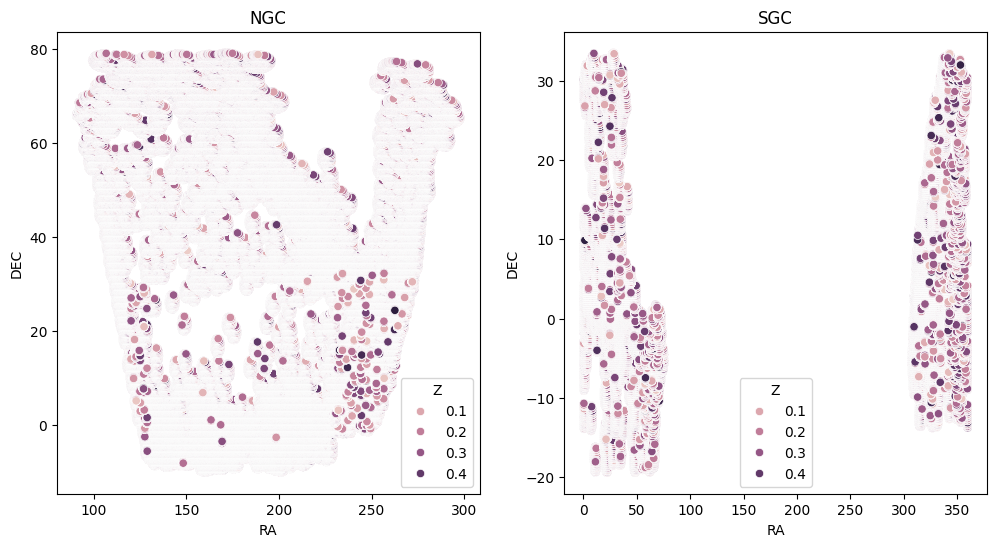

In [3]:
names = ["RA","DEC","Z"]
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.scatterplot(NGC[names].to_pandas(), x="RA", y="DEC", hue="Z", ax=ax[0])
ax[0].set_title('NGC')
sns.scatterplot(SGC[names].to_pandas(), x="RA", y="DEC", hue="Z", ax=ax[1])
ax[1].set_title('SGC');

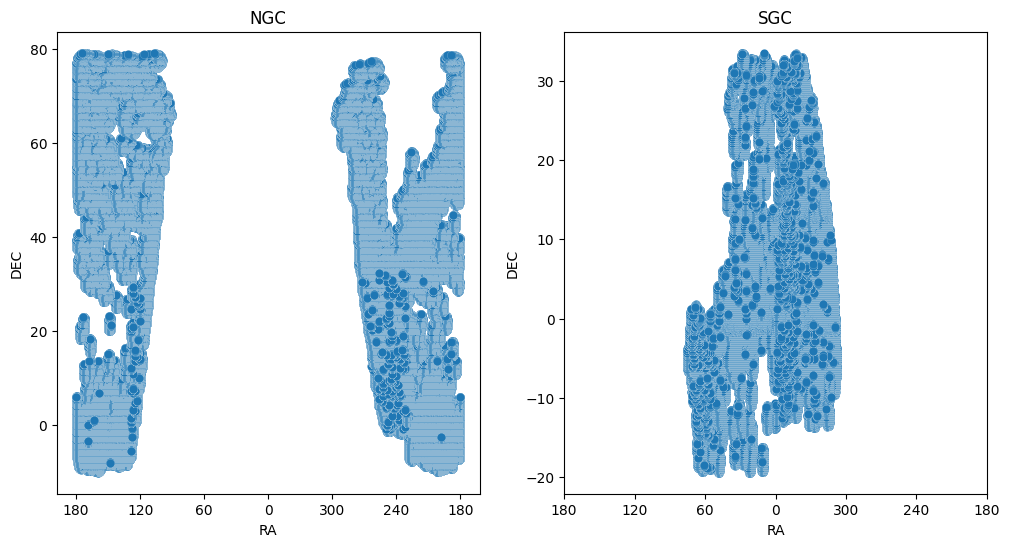

In [3]:
def recenter_RA(RA):
    return np.where(RA > 180,RA - 360, RA)

def plot_RADEC(RA, DEC, title='', RA_recenter=True, all_sky=True, **kwargs):
    if "figax" in kwargs.keys(): fig, ax = kwargs.pop("figax")
    else: fig, ax = plt.subplots()
    grid = kwargs.pop("grid", False)
    if RA_recenter: #make 360° correspond with 0°
        RA = RA.copy() #to not affect the data itself
        RA = recenter_RA(RA)
        RA_ticks = np.arange(-180, 201, 60)
        RA_labels = (RA_ticks + 360) % 360
    else:
        RA_ticks = np.arange(0, 361, 60)
        RA_labels = RA_ticks
    DEC_ticks = np.arange(-90, 91, 30)
    ax.scatter(RA, DEC, edgecolors='white', linewidths=0.1)
    if all_sky or RA_recenter:
        ax.set_xticks(RA_ticks)
        ax.set_xticklabels(RA_labels)
    if all_sky: ax.set_yticks(DEC_ticks)
    ax.invert_xaxis()
    ax.set_title(title)
    ax.set_xlabel("RA")
    ax.set_ylabel("DEC")
    if grid: ax.grid()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
plot_RADEC(NGC["RA"], NGC["DEC"], title="NGC", figax = (fig, ax[0]), all_sky=False)
plot_RADEC(SGC["RA"], SGC["DEC"], title="SGC", figax = (fig, ax[1]), all_sky=False)

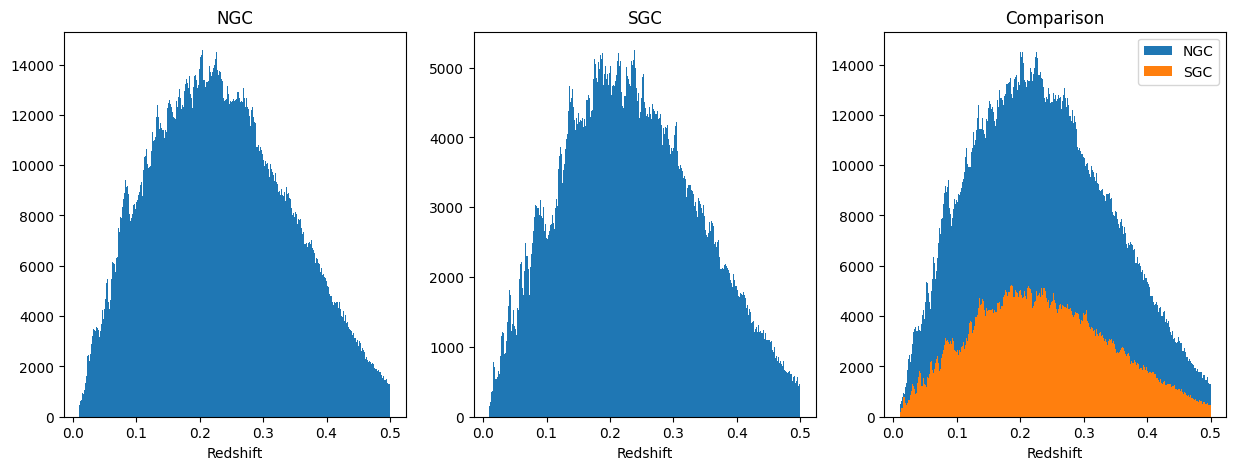

In [4]:
def histCompare_NS(col, xlabel, category=False, **kwargs):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    xscale = kwargs.pop('xscale', "linear")
    if category: #qualitative variables
        sns.countplot(NGC[[col]].to_pandas(), x=col, ax=ax[0])
        ax[0].set_title("NGC")
        sns.countplot(SGC[[col]].to_pandas(), x=col, ax=ax[1])
        ax[1].set_title("SGC")
        sns.countplot(NGC[[col]].to_pandas(), x=col, ax=ax[2], label="NGC")
        sns.countplot(SGC[[col]].to_pandas(), x=col, ax=ax[2], label="SGC")
        ax[2].set_title("Comparison")
    else: #quantitative variables
        get_hist(NGC[col], xlabel=xlabel, title="NGC", show=False, figax = (fig, ax[0]), **kwargs)
        get_hist(SGC[col], xlabel=xlabel, title="SGC", show=False, figax = (fig, ax[1]), **kwargs)
        get_hist(NGC[col], xlabel=xlabel, title="Comparison", show=False, figax = (fig, ax[2]), label="NGC", **kwargs)
        get_hist(SGC[col], xlabel=xlabel, title="Comparison", show=False, figax = (fig, ax[2]), label="SGC", **kwargs)
        ax[2].legend()
        ax[0].set_xscale(xscale)
        ax[1].set_xscale(xscale)
        ax[2].set_xscale(xscale)
    return fig, ax

histCompare_NS("Z", "Redshift", bins=500);

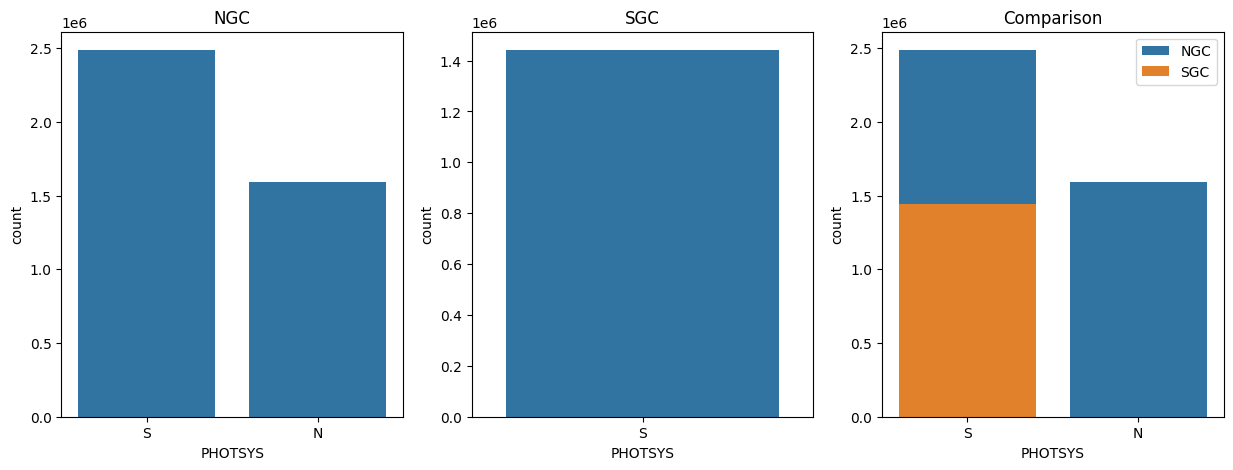

In [5]:
histCompare_NS("PHOTSYS", "PHOTSYS", category=True);

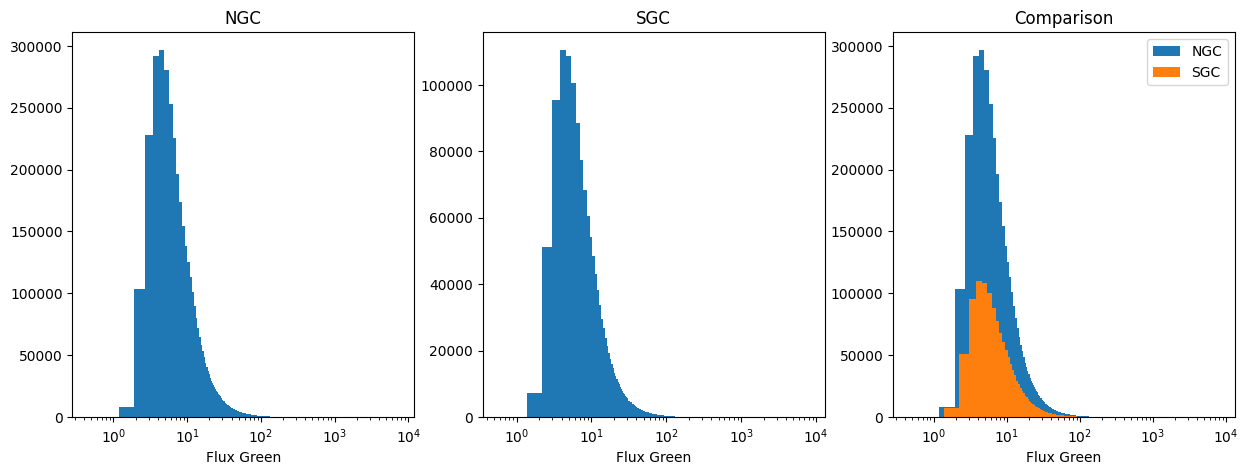

In [6]:
histCompare_NS("flux_g_dered", "Flux Green", bins=10000, xscale="log");

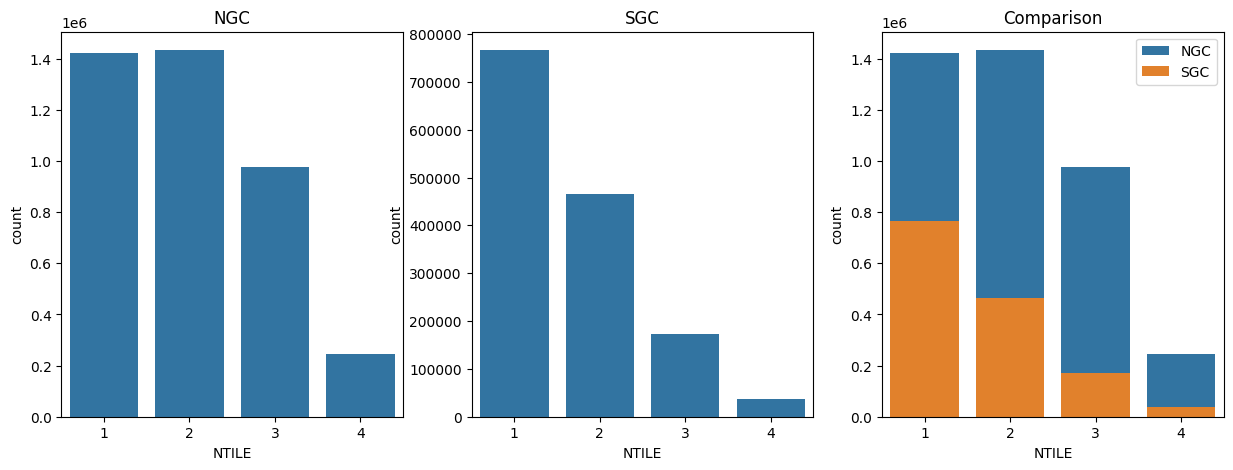

In [6]:
histCompare_NS("NTILE", "NTILE", category=True);

## Maps

In [3]:
NSIDE = 128
NPIX = hp.nside2npix(NSIDE)
area_deg2 = hp.nside2pixarea(NSIDE, degrees=True)
print("Number of pixels = {}".format(NPIX))
print("Surface of a pixel = {} deg^2".format(area_deg2))

Number of pixels = 196608
Surface of a pixel = 0.2098234113027917 deg^2


In [4]:
NSource_NGC = RADEC2NSource_Table(NSIDE, NGC, nest=True)
NSource_SGC = RADEC2NSource_Table(NSIDE, SGC, nest=True)
NSource_NGC_px, NSource_SGC_px = NSource_NGC/area_deg2, NSource_SGC/area_deg2

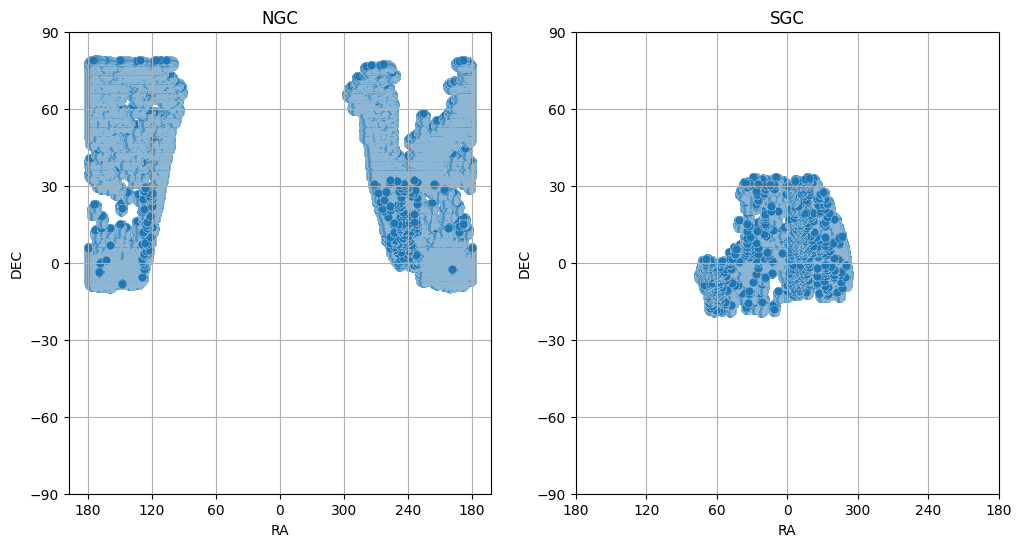

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
plot_RADEC(NGC["RA"], NGC["DEC"], title="NGC", figax = (fig, ax[0]), grid=True)
plot_RADEC(SGC["RA"], SGC["DEC"], title="SGC", figax = (fig, ax[1]), grid=True)

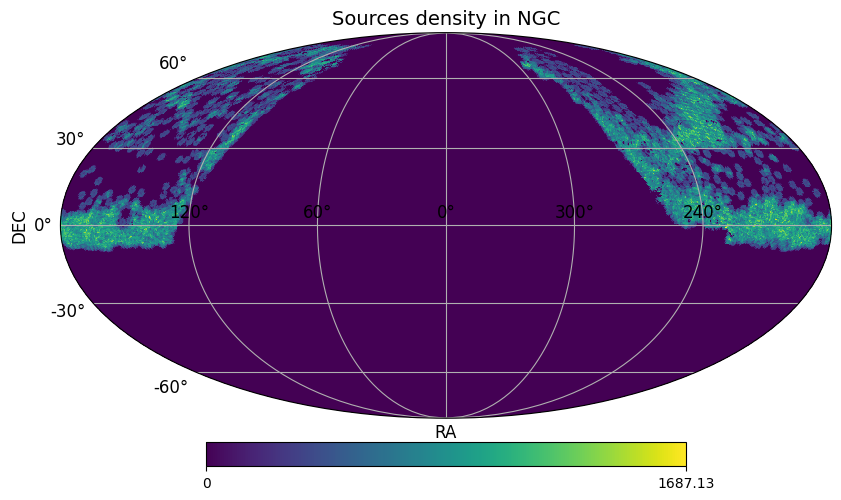

In [9]:
hp.projview(NSource_NGC_px, title="Sources density in NGC", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide")
plt.xlabel("RA")
plt.ylabel("DEC");

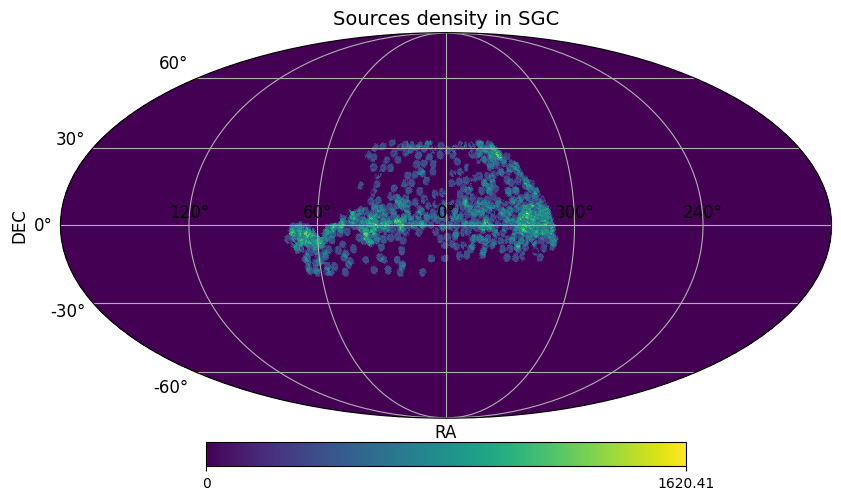

In [8]:
hp.projview(NSource_SGC_px, title="Sources density in SGC", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide")
plt.xlabel("RA")
plt.ylabel("DEC");

Saving Source_Density_map in Data DESI/DESI Figures/DESI_DR1_BGS_Source_Density_map.pdf


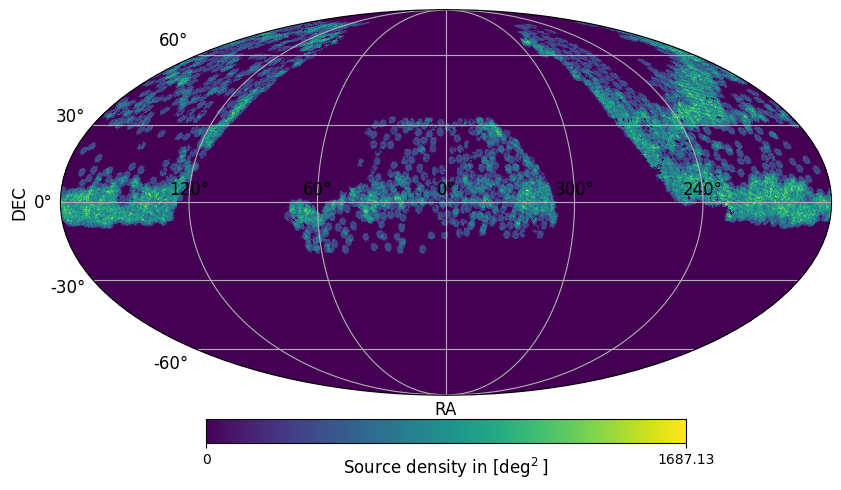

In [9]:
hp.projview(NSource_NGC_px+NSource_SGC_px, unit="Source density in $[\deg^2]$", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide")
plt.xlabel("RA")
plt.ylabel("DEC")
#plt.savefig(outputDIR + "DESI_DR1_BGS_Source_Density_map.pdf", bbox_inches='tight');
get_savefig(plt, output_path, "Source_Density_map");

### Other analysis:

In [25]:
#addinf pixel number by source:
px_colname = "px_Nside{}".format(NSIDE)
NGC.add_column(hp.ang2pix(NSIDE, NGC['RA'], NGC['DEC'], lonlat=True, nest=True), name=px_colname)
NGC[px_colname].unit = None
SGC.add_column(hp.ang2pix(NSIDE, SGC['RA'], SGC['DEC'], lonlat=True, nest=True), name=px_colname)
SGC[px_colname].unit = None
NGC

TARGETID,Z,NTILE,RA,DEC,PHOTSYS,FRAC_TLOBS_TILES,WEIGHT_ZFAIL,BITWEIGHTS,PROB_OBS,WEIGHT,WEIGHT_COMP,WEIGHT_SYS,flux_g_dered,flux_r_dered,flux_z_dered,flux_w1_dered,flux_w2_dered,NX,WEIGHT_FKP,px_Nside128
,,,deg,deg,,,,,,,,,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy,,,
int64,float64,int64,float64,float64,bytes1,float64,float64,int64[2],float64,float64,float64,float64,float32,float32,float32,float32,float32,float64,float64,int64
39627540901396542,0.11780978798091779,1,159.21336539688306,-10.1570784990642,S,0.986125385405961,1.0,-1 .. -1,1.0,0.4020310943321785,1.0,1.0,49.759033,82.394775,123.07306,107.12112,72.68243,0.013277792318345803,0.010644577467738883,106913
39627540901396881,0.18852438367491672,1,159.31752567050466,-10.126518405884719,S,0.986125385405961,1.0003317594528198,-1 .. -1,1.0,0.40216447194805066,1.0,1.0,4.465552,9.0119915,15.1033325,19.139269,17.25489,0.007570508503506765,0.01852072744982418,106913
39627546827951381,0.13939738520826428,1,157.87076725654435,-9.875451258938376,S,0.98491921005386,1.0000087022781372,-1 .. -1,1.0,0.4020345929185812,1.0,1.0,21.879585,30.944036,39.23734,31.118029,17.95399,0.011543794958537013,0.012223957863869393,106922
39627546832142517,0.13384342727980247,1,157.95311366416092,-9.89176181427952,S,0.98491921005386,1.0,-6502010112314306597 .. -7014319551088676288,0.34375,1.1524891370855783,2.8666666666666667,1.0,64.23985,161.47015,326.29388,286.1153,183.32571,0.011543794958537013,0.012223957863869393,106920
39627546832142599,0.13481237197080895,1,157.95938723949703,-9.900573678838345,S,0.98491921005386,1.0000147819519043,-1158348146330124321 .. -90865853993600030,0.6875,0.5827278403438851,1.449438202247191,1.0,13.473231,20.69669,29.218834,22.669884,17.1243,0.011543794958537013,0.012223957863869393,106920
39627546832144102,0.3277038731563745,1,158.0586254092098,-9.883478054340443,S,0.98491921005386,1.0,-1 .. -1,1.0,0.4020310943321785,1.0,1.0,4.8808885,13.26394,26.47439,35.094788,26.350426,0.0020923038580991644,0.0639135806306668,106920
39627546832144556,0.2804423196541022,1,158.0919034157211,-9.885985138196315,S,0.98491921005386,1.0000360012054443,-1 .. -1,1.0,0.40204556793620055,1.0,1.0,4.8884478,10.819805,16.304056,14.631474,10.874418,0.0033096766342485067,0.041377478709825624,106920
39627546832144612,0.1756295118675194,1,158.09744754077613,-9.948586941938014,S,0.98491921005386,1.0000108480453491,-8354376908713272321 .. -8487356173256100561,0.5390625,0.7408939110042868,1.8428571428571427,1.0,19.048483,29.186644,40.23485,27.274828,21.075787,0.008095592993999081,0.0173402934391804,106920


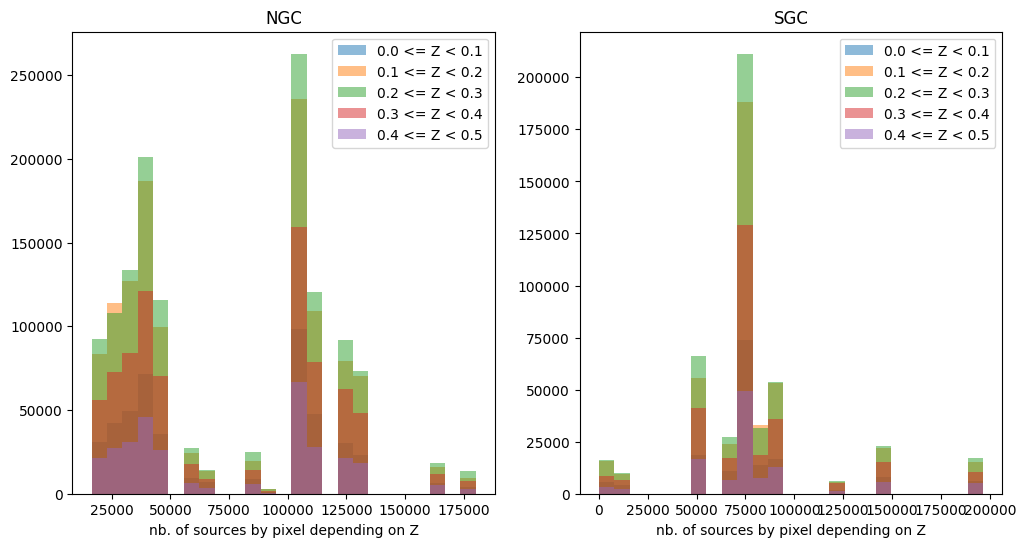

In [26]:
npins = 5
Z_lim = (np.arange(0, npins, 1).reshape([-1,1]))/10
masks_NGC = (NGC["Z"] >= Z_lim) & (NGC["Z"] < Z_lim+0.1)
masks_SGC = (SGC["Z"] >= Z_lim) & (SGC["Z"] < Z_lim+0.1)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
xlabel = "nb. of sources by pixel depending on Z"
bins = 25
for i in range(npins):
    label = "{} <= Z < {}".format(np.round(Z_lim[i, 0], 1), np.round(Z_lim[i, 0]+0.1, 1))
    ax[0].hist(NGC[px_colname][masks_NGC[i]], label=label, bins=bins, alpha=0.5)
    ax[0].set_title("NGC")
    ax[0].set_xlabel(xlabel)
    ax[0].legend()
    ax[1].hist(SGC[px_colname][masks_SGC[i]], label=label, bins=bins, alpha=0.5)
    ax[1].set_title("SGC")
    ax[1].set_xlabel(xlabel)
    ax[1].legend()